# PSI Thin-Limit Scan, Cylindrical Monitor

Extract the 10 `PSI_thinlimit_1e7` runs, read the sample radius, height, and wall thickness from each `mccode.sim`, and compute the expected intensity in one cylindrical-monitor radial-angle bin.

The Born estimate is the same as in `thinlimit_4PImon.ipynb`:

`expected = intensity_hitting_sample * P_interact * solid_angle_bin / (4*pi)`

For the cylindrical monitor, the bin solid angle is integrated over the selected `Y` strip using `dOmega = R^2 dphi dy / (R^2 + y^2)^(3/2)`.


In [80]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

run_root = Path('PSI_thinlimit_1e8')
if not run_root.exists():
    run_root = Path('geometry_optimization/PSI_instrument/thinlimit/PSI_thinlimit_1e8')

# Same constants/conventions used in thinlimit_4PImon.ipynb.
sigma_inc_cm_inv = 0.367
sigma_abs_cm_inv = sigma_inc_cm_inv
sigma_coh_cm_inv = 1.786e-3
sigma_total_cm_inv = sigma_inc_cm_inv + sigma_abs_cm_inv + sigma_coh_cm_inv
use_linear_probability = False
include_lids = True
# Lid thickness as a percentage of the cylindrical wall thickness.
lid_thickness_percent_of_wall = 100.0

# Cyl_monitor_PSD settings in FullInstrument_v5_working.instr.
cyl_monitor_radius_m = 1.0
y_cut_halfwidth_m = 2.0
window_center_deg = 75.0
window_width_deg = 60.0
drop_last_zero_angle_bin = True

mask_direct_beam = True
direct_beam_center_cylinder = (0.0, 0.0)
direct_beam_cylinder_width_deg = 10.0
direct_beam_cylinder_height_m = 0.20

print(run_root.resolve())


/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/thinlimit/PSI_thinlimit_1e8


In [81]:
def parse_mccode_params(sim_file):
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with Path(sim_file).open('r') as f:
        for line in f:
            match = pattern.match(line)
            if match:
                try:
                    params[match.group(1)] = float(match.group(2))
                except ValueError:
                    pass
    return params


def _parse_float_tuple(text, n):
    return tuple(float(value) for value in text.split(':', 1)[1].split()[:n])


def parse_mccode_dat(path):
    path = Path(path)
    lines = path.read_text(errors='ignore').splitlines()
    meta = {'path': path}
    monitor_type = None
    nx = ny = None

    for line in lines:
        if line.startswith('# type:'):
            monitor_type = line.split(':', 1)[1].strip()
            dim_match = re.search(r'array_(1d|2d)\(([^)]*)\)', monitor_type)
            if dim_match:
                dims = [int(value.strip()) for value in dim_match.group(2).split(',') if value.strip()]
                nx = dims[0] if dims else None
                ny = dims[1] if len(dims) > 1 else None
        elif line.startswith('# component:'):
            meta['component'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlabel:'):
            meta['xlabel'] = line.split(':', 1)[1].strip()
        elif line.startswith('# ylabel:'):
            meta['ylabel'] = line.split(':', 1)[1].strip()
        elif line.startswith('# xlimits:'):
            meta['xlimits'] = _parse_float_tuple(line, 2)
        elif line.startswith('# xylimits:'):
            meta['xylimits'] = _parse_float_tuple(line, 4)
        elif line.startswith('# values:'):
            values = [float(value) for value in line.split(':', 1)[1].split()[:3]]
            meta['header_total'] = values[0]
            meta['header_error'] = values[1] if len(values) > 1 else np.nan
            meta['header_counts'] = values[2] if len(values) > 2 else np.nan

    data_start = None
    for index, line in enumerate(lines):
        if line.startswith('# Data') and line.rstrip().endswith('I:'):
            data_start = index + 1
            break
    if data_start is None:
        raise ValueError(f'Could not find intensity section in {path}')

    rows = []
    for line in lines[data_start:]:
        stripped = line.strip()
        if stripped and not stripped.startswith('#'):
            rows.append([float(value) for value in stripped.split()])
    data = np.array(rows, dtype=float)

    if monitor_type and monitor_type.startswith('array_1d'):
        x = data[:, 0] if data.ndim == 2 and data.shape[1] >= 2 else np.arange(data.size)
        intensity = data[:, 1] if data.ndim == 2 and data.shape[1] >= 2 else data.reshape(-1)
        meta.update({'kind': '1d', 'x': x, 'I': intensity, 'total': float(np.nansum(intensity))})
        return meta

    intensity = data[:ny, :] if ny is not None and data.shape[0] >= ny else data
    error = data[ny:2 * ny, :] if ny is not None and data.shape[0] >= 2 * ny else None
    counts = data[2 * ny:3 * ny, :] if ny is not None and data.shape[0] >= 3 * ny else None
    meta.update({'kind': '2d', 'I': intensity, 'I_err': error, 'N': counts, 'total': float(np.nansum(intensity))})
    return meta


def record_total(record):
    return float(record.get('header_total', record['total']))


def record_total_error(record):
    if np.isfinite(record.get('header_error', np.nan)):
        return float(record['header_error'])
    if record.get('I_err') is not None:
        return float(np.sqrt(np.nansum(np.asarray(record['I_err'], dtype=float) ** 2)))
    return np.nan


def load_records(run_dir):
    records = {}
    for dat_file in Path(run_dir).glob('*.dat'):
        record = parse_mccode_dat(dat_file)
        records[dat_file.stem] = record
        if record.get('component'):
            records[record['component']] = record
    return records


def first_available_record(records, names):
    for name in names:
        if name in records:
            return records[name]
    raise KeyError(f'None of these records were found: {names}')


def coordinate_centers(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    n_y, n_x = record['I'].shape
    x_edges = np.linspace(x_min, x_max, n_x + 1)
    y_edges = np.linspace(y_min, y_max, n_y + 1)
    return 0.5 * (x_edges[:-1] + x_edges[1:]), 0.5 * (y_edges[:-1] + y_edges[1:]), x_edges, y_edges


In [82]:
def geometry_cm(run_dir):
    params = parse_mccode_params(Path(run_dir) / 'mccode.sim')
    return {
        'outer_radius_cm': params['sampleRadius'] * 100.0,
        'outer_height_cm': params['sampleHeight'] * 100.0,
        'wall_thickness_cm': params['sampleThickness'] * 100.0,
    }


def side_wall_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    H = geometry['outer_height_cm']
    t = geometry['wall_thickness_cm']
    r = R - t
    if r <= 0:
        return np.nan
    return np.pi * (R**2 - r**2) * H


def lid_thickness_cm(geometry):
    return geometry['wall_thickness_cm'] * lid_thickness_percent_of_wall / 100.0


def lid_volume_cm3(geometry):
    R = geometry['outer_radius_cm']
    t_lid = lid_thickness_cm(geometry)
    if t_lid <= 0:
        return 0.0
    return 2.0 * np.pi * R**2 * t_lid


def sample_material_volume_cm3(geometry):
    volume = side_wall_volume_cm3(geometry)
    if include_lids:
        volume += lid_volume_cm3(geometry)
    return volume


def projected_area_cm2(geometry):
    return 2.0 * geometry['outer_radius_cm'] * geometry['outer_height_cm']


def mean_path_length_cm(geometry):
    return sample_material_volume_cm3(geometry) / projected_area_cm2(geometry)


def interaction_probability(geometry):
    length = mean_path_length_cm(geometry)
    if use_linear_probability:
        return sigma_inc_cm_inv * length
    total_probability = 1.0 - np.exp(-sigma_total_cm_inv * length)
    return total_probability * sigma_inc_cm_inv / sigma_total_cm_inv


def intensity_hitting_sample(records):
    before = records['sample_flux_before']
    after = records['sample_flux_after_unscattered']
    before_total = record_total(before)
    after_total = record_total(after)
    before_error = record_total_error(before)
    after_error = record_total_error(after)
    error = np.sqrt(before_error**2 + after_error**2) if np.isfinite(before_error) and np.isfinite(after_error) else np.nan
    return before_total - after_total, error, before_total, after_total


def y_mask(record):
    _, y_centers, _, _ = coordinate_centers(record)
    return np.abs(y_centers) <= y_cut_halfwidth_m


def cylindrical_band_solid_angle_per_radial_bin_sr(record, selected_y_mask):
    x_min, x_max, _, _ = record['xylimits']
    n_y, n_phi = record['I'].shape
    dphi = np.deg2rad((x_max - x_min) / n_phi)
    _, _, _, y_edges = coordinate_centers(record)
    R = cyl_monitor_radius_m

    omega = 0.0
    for i, use_bin in enumerate(selected_y_mask):
        if not use_bin:
            continue
        y1 = y_edges[i]
        y2 = y_edges[i + 1]
        omega += dphi * (y2 / np.sqrt(R**2 + y2**2) - y1 / np.sqrt(R**2 + y1**2))
    return float(omega)


def observed_y_band_profile(record, selected_y_mask):
    phi_centers, y_centers, _, _ = coordinate_centers(record)
    image = np.asarray(record['I'], dtype=float).copy()
    error = None if record.get('I_err') is None else np.asarray(record['I_err'], dtype=float).copy()

    if mask_direct_beam:
        center_phi, center_y = direct_beam_center_cylinder
        phi_beam = np.abs(angular_delta_deg(phi_centers, center_phi)) <= direct_beam_cylinder_width_deg / 2.0
        y_beam = np.abs(y_centers - center_y) <= direct_beam_cylinder_height_m / 2.0
        beam_mask = np.outer(y_beam, phi_beam)
        image[beam_mask] = np.nan
        if error is not None:
            error[beam_mask] = np.nan

    profile = np.nansum(image[selected_y_mask, :], axis=0)
    profile_error = None if error is None else np.sqrt(np.nansum(error[selected_y_mask, :] ** 2, axis=0))
    if drop_last_zero_angle_bin:
        phi_centers = phi_centers[:-1]
        profile = profile[:-1]
        if profile_error is not None:
            profile_error = profile_error[:-1]
    return phi_centers, profile, profile_error


def angular_delta_deg(values, center):
    return (values - center + 180.0) % 360.0 - 180.0


def symmetric_window_mask(angle):
    half_width = window_width_deg / 2.0
    positive = np.abs(angular_delta_deg(angle, window_center_deg)) <= half_width
    negative = np.abs(angular_delta_deg(angle, -window_center_deg)) <= half_width
    return positive | negative


def expected_intensity_for_run(run_dir):
    records = load_records(run_dir)
    cylmon = first_available_record(records, ('sample_cylinder_monitor_scattered', 'sample_cylinder_monitor'))
    geometry = geometry_cm(run_dir)
    hit, hit_error, before, after = intensity_hitting_sample(records)
    selected_y = y_mask(cylmon)
    omega = cylindrical_band_solid_angle_per_radial_bin_sr(cylmon, selected_y)
    probability = interaction_probability(geometry)
    expected = hit * probability * omega / (4.0 * np.pi)

    angle, profile, profile_error = observed_y_band_profile(cylmon, selected_y)
    angle_mask = symmetric_window_mask(angle)
    observed_mean = float(np.nanmean(profile[angle_mask]))
    observed_mean_error = np.nan
    if profile_error is not None:
        observed_mean_error = float(np.sqrt(np.nansum(profile_error[angle_mask] ** 2)) / np.count_nonzero(angle_mask))

    return {
        'run': int(Path(run_dir).name),
        'radius_cm': geometry['outer_radius_cm'],
        'height_cm': geometry['outer_height_cm'],
        'thickness_cm': geometry['wall_thickness_cm'],
        'lid_thickness_cm': lid_thickness_cm(geometry) if include_lids else 0.0,
        'side_wall_volume_cm3': side_wall_volume_cm3(geometry),
        'lid_volume_cm3': lid_volume_cm3(geometry) if include_lids else 0.0,
        'material_volume_cm3': sample_material_volume_cm3(geometry),
        'mean_path_cm': mean_path_length_cm(geometry),
        'P_interact': probability,
        'I_before': before,
        'I_after_unscattered': after,
        'I_hit': hit,
        'I_hit_err': hit_error,
        'cyl_monitor_radius_m': cyl_monitor_radius_m,
        'y_cut_halfwidth_m': y_cut_halfwidth_m,
        'solid_angle_per_radial_bin_sr': omega,
        'expected_per_radial_bin': expected,
        'observed_window_mean_per_radial_bin': observed_mean,
        'observed_window_mean_err': observed_mean_error,
        'observed_over_expected': observed_mean / expected if expected > 0 else np.nan,
        'n_window_bins': int(np.count_nonzero(angle_mask)),
        'n_y_bins': int(np.count_nonzero(selected_y)),
    }


In [83]:
expected_run_count = 7
run_dirs = sorted([path for path in run_root.iterdir() if path.is_dir() and path.name.isdigit()], key=lambda path: int(path.name))
results = pd.DataFrame(expected_intensity_for_run(run_dir) for run_dir in run_dirs)

display(results)

print(f'Runs: {len(results)}')
print(f"Radius: {results['radius_cm'].iloc[0]:.6g} cm")
print(f"Height: {results['height_cm'].iloc[0]:.6g} cm")
print(f"Thickness range: {results['thickness_cm'].min():.6g} to {results['thickness_cm'].max():.6g} cm")
print(f"Include lids: {include_lids}")
print(f"Lid thickness: {lid_thickness_percent_of_wall:g}% of wall thickness")
print(f"Cylindrical monitor radius: {cyl_monitor_radius_m:.6g} m")
print(f"Y cut: |Y| <= {y_cut_halfwidth_m:.6g} m")
print(f"Solid angle per radial bin: {results['solid_angle_per_radial_bin_sr'].iloc[0]:.6g} sr")


,run,radius_cm,height_cm,thickness_cm,side_wall_volume_cm3,lid_volume_cm3,material_volume_cm3,mean_path_cm,P_interact,I_before,...,I_hit_err,cyl_monitor_radius_m,y_cut_halfwidth_m,solid_angle_per_radial_bin_sr,expected_per_radial_bin,observed_window_mean_per_radial_bin,observed_window_mean_err,observed_over_expected,n_window_bins,n_y_bins
0,0,1.0,1.0,0.000100,0.000628,0.000628,0.001257,0.000628,0.000231,45985700.0,...,23395.773094,1.0,2.0,0.062443,12.052714,11.492269,0.009927,0.953501,62,72
1,1,1.0,1.0,0.002575,0.016158,0.016179,0.032338,0.016169,0.005899,45979800.0,...,23394.497371,1.0,2.0,0.062443,308.023742,273.926774,0.151085,0.889304,62,72
2,2,1.0,1.0,0.005050,0.031650,0.031730,0.063380,0.031690,0.011496,45998800.0,...,23397.527894,1.0,2.0,0.062443,600.272550,505.437980,0.242299,0.842014,62,72
3,3,1.0,1.0,0.007525,0.047103,0.047281,0.094384,0.047192,0.017022,45996700.0,...,23397.900065,1.0,2.0,0.062443,889.664372,720.681250,0.318843,0.810060,62,72
4,4,1.0,1.0,0.010000,0.062518,0.062832,0.125350,0.062675,0.022479,45974400.0,...,23390.987175,1.0,2.0,0.062443,1173.661918,920.372533,0.380701,0.784189,62,72


Runs: 5
Radius: 1 cm
Height: 1 cm
Thickness range: 0.0001 to 0.01 cm
Include lids: True
Cylindrical monitor radius: 1 m
Y cut: |Y| <= 2 m
Solid angle per radial bin: 0.0624428 sr


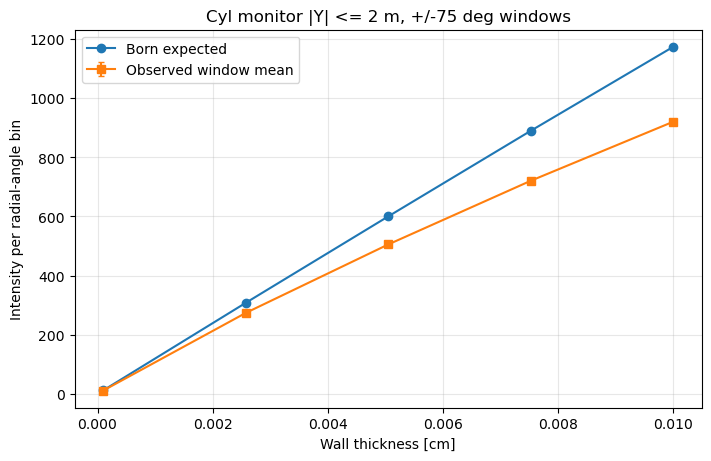

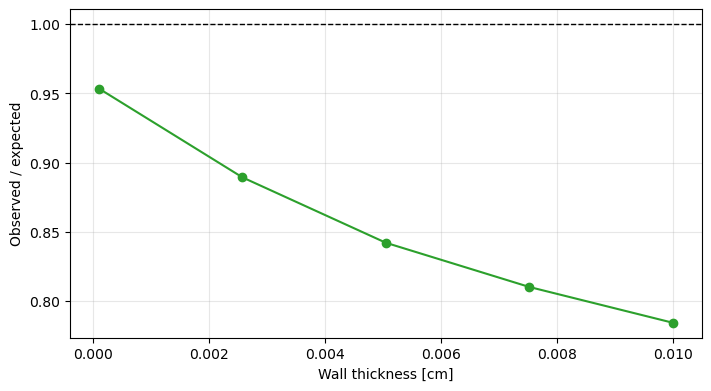

In [84]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(results['thickness_cm'], results['expected_per_radial_bin'], 'o-', label='Born expected')
ax.errorbar(
    results['thickness_cm'],
    results['observed_window_mean_per_radial_bin'],
    yerr=results['observed_window_mean_err'],
    fmt='s-',
    capsize=2,
    label='Observed window mean',
)
ax.set_xlabel('Wall thickness [cm]')
ax.set_ylabel('Intensity per radial-angle bin')
ax.set_title(f'Cyl monitor |Y| <= {y_cut_halfwidth_m:g} m, +/-{window_center_deg:g} deg windows')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
ax.plot(results['thickness_cm'], results['observed_over_expected'], 'o-', color='tab:green')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Wall thickness [cm]')
ax.set_ylabel('Observed / expected')
ax.set_title('Cylindrical monitor observed/Born ratio vs wall thickness')
ax.grid(alpha=0.3)
plt.show()


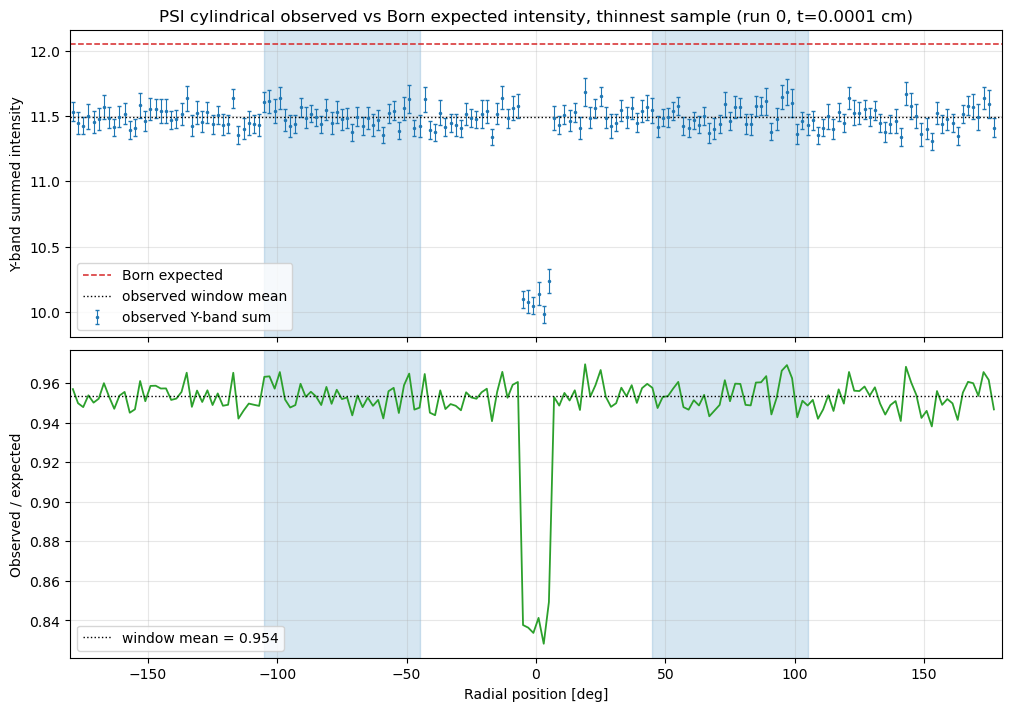

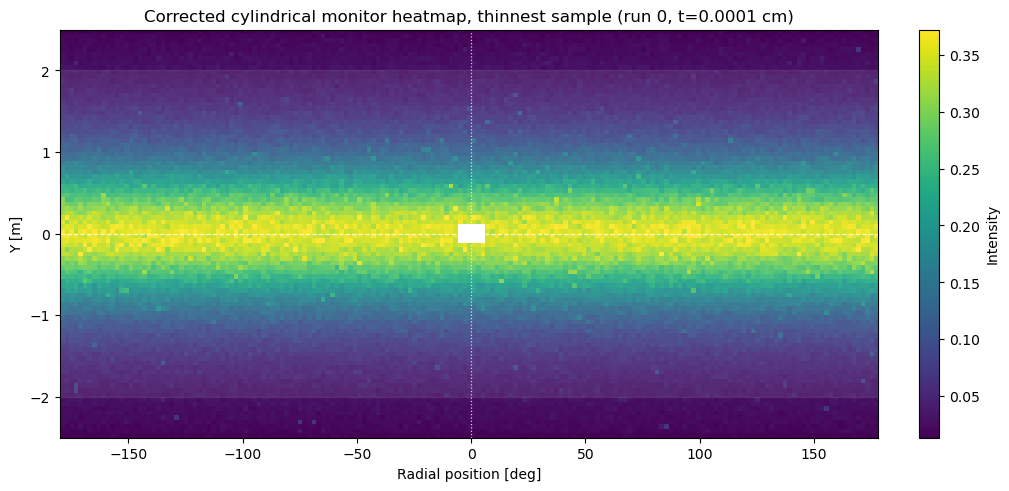

In [85]:
# Observed profile vs Born expected for the thinnest sample.
thinnest = results.loc[results['thickness_cm'].idxmin()]
thinnest_run_dir = run_root / str(int(thinnest['run']))
records = load_records(thinnest_run_dir)
cylmon = first_available_record(records, ('sample_cylinder_monitor_scattered', 'sample_cylinder_monitor'))

selected_y = y_mask(cylmon)
angle, profile, profile_error = observed_y_band_profile(cylmon, selected_y)
angle_mask = symmetric_window_mask(angle)

expected = float(thinnest['expected_per_radial_bin'])
observed_mean = float(np.nanmean(profile[angle_mask]))
ratio = observed_mean / expected if expected > 0 else np.nan
valid = np.isfinite(profile) & (profile != 0.0)
ratio_values = np.full_like(profile, np.nan, dtype=float)
if expected > 0:
    ratio_values[valid] = profile[valid] / expected

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

if profile_error is not None:
    axs[0].errorbar(
        angle[valid],
        profile[valid],
        yerr=profile_error[valid],
        fmt='.',
        markersize=3,
        linewidth=0.8,
        capsize=1.5,
        label='observed Y-band sum',
    )
else:
    axs[0].plot(angle[valid], profile[valid], '.', markersize=3, label='observed Y-band sum')

for ax in axs:
    ax.axvspan(window_center_deg - window_width_deg / 2, window_center_deg + window_width_deg / 2, alpha=0.18, color='tab:blue')
    ax.axvspan(-window_center_deg - window_width_deg / 2, -window_center_deg + window_width_deg / 2, alpha=0.18, color='tab:blue')

axs[0].axhline(expected, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
axs[0].axhline(observed_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
axs[0].set_title(
    'PSI cylindrical observed vs Born expected intensity, thinnest sample '
    f'(run {int(thinnest["run"])}, t={thinnest["thickness_cm"]:.6g} cm)'
)
axs[0].set_ylabel('Y-band summed intensity')
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='best')

axs[1].plot(angle[valid], ratio_values[valid], color='tab:green', lw=1.3)
axs[1].axhline(ratio, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio:.3g}')
axs[1].set_xlabel('Radial position [deg]')
axs[1].set_ylabel('Observed / expected')
axs[1].set_xlim(-180, 180)
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='best')
plt.show()

# Corrected heatmap for the thinnest sample, using the same masking/cropping as the profile.
phi_centers, y_centers, phi_edges, y_edges = coordinate_centers(cylmon)
corrected_image = np.asarray(cylmon['I'], dtype=float).copy()

if mask_direct_beam:
    center_phi, center_y = direct_beam_center_cylinder
    phi_beam = np.abs(angular_delta_deg(phi_centers, center_phi)) <= direct_beam_cylinder_width_deg / 2.0
    y_beam = np.abs(y_centers - center_y) <= direct_beam_cylinder_height_m / 2.0
    corrected_image[np.outer(y_beam, phi_beam)] = np.nan

if drop_last_zero_angle_bin:
    corrected_image = corrected_image[:, :-1]
    phi_centers = phi_centers[:-1]
    phi_edges = phi_edges[:-1]

vmin = np.nanpercentile(corrected_image, 1.0)
vmax = np.nanpercentile(corrected_image, 99.5)
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.imshow(
    corrected_image,
    origin='lower',
    aspect='auto',
    extent=[phi_edges[0], phi_edges[-1], y_edges[0], y_edges[-1]],
    interpolation='nearest',
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
)
ax.axhline(0.0, color='white', linestyle='--', linewidth=0.9, alpha=0.8)
ax.axvline(0.0, color='white', linestyle=':', linewidth=0.9, alpha=0.8)
ax.axhspan(-y_cut_halfwidth_m, y_cut_halfwidth_m, color='white', alpha=0.08)
ax.set_title(
    'Corrected cylindrical monitor heatmap, thinnest sample '
    f'(run {int(thinnest["run"])}, t={thinnest["thickness_cm"]:.6g} cm)'
)
ax.set_xlabel('Radial position [deg]')
ax.set_ylabel('Y [m]')
fig.colorbar(im, ax=ax, label='Intensity')
plt.show()
